In [7]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load data
adata = sc.read_h5ad("Senescent.h5ad")


# Function to map treatment strings to numeric
def map_treatment(val):
    if val in ["0", "control"]:   # just in case "0" is stored as string
        return 0
    if isinstance(val, str) and val.endswith("day"):
        return int(val.replace("day", ""))
    return None  # fallback for unexpected entries

adata.obs["treatment_numeric"] = adata.obs["treatment"].apply(map_treatment)
adata.obs["treatment_numeric"] = adata.obs["treatment_numeric"].astype(int)

# Filter rows with treatment <= 11
mask = adata.obs["treatment_numeric"] <= 11
adata_sub = adata[mask].copy()

# Expression matrix as pandas DF
if hasattr(adata_sub.X, "toarray"):  # sparse matrix
    X = pd.DataFrame(
        adata_sub.X.toarray(),
        index=adata_sub.obs_names,
        columns=adata_sub.var_names
    )
else:
    X = pd.DataFrame(
        adata_sub.X,
        index=adata_sub.obs_names,
        columns=adata_sub.var_names
    )

# Treatment vector (numeric)
Z = adata_sub.obs["treatment_numeric"]

print(X.shape)   # filtered expression matrix
X_arr = np.array(X)
Z_arr = np.array(Z)

(6000, 84)


/opt/homebrew/Caskroom/miniconda/base/envs/jupyter_env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [5]:
feature_names = X.columns

# Filter
filtered_features = [
    col for col in feature_names
    if "total_nuc_protein" not in col
    and "nuc_cyto_ratio" not in col
    and 'ratio' not in col
    and not (col.startswith("R") and col.endswith("DNA_nuc_mean") and col != "R0_DNA_nuc_mean")

]


X_filtered = X[filtered_features]

X_all = np.array(X_filtered)

In [12]:
# ----- helpers -----
def _second_moment(X_group, center):
    n_g = X_group.shape[0]
    if n_g == 0:
        raise ValueError("Encountered an empty group.")
    if center:
        Xc = (X_group - X_group.mean(axis=0, keepdims=True))#/X_group.std(0)
        return (Xc.T @ Xc) / n_g
    else:
        return (X_group.T @ X_group) #/ n_g

def compute_CLA_matrix(X, Z, center=True, beta = 1):
    X = np.asarray(X); Z = np.asarray(Z)
    ctrl = (Z == 0)
    trt  = (Z > 0)

    Sigma0 = _second_moment(X[ctrl], center=center)
    z_treated = Z[trt]
    X_treated = X[trt]
    uniq = np.unique(z_treated)

    p = X.shape[1]
    n_plus = float(trt.sum())
    T = np.zeros((p, p), dtype=float)
    for z_val in uniq:
        idx = (z_treated == z_val)
        n_z = float(idx.sum())
        Sigma_z = _second_moment(X_treated[idx], center=center)
        print(n_z)
        T += (Sigma_z - Sigma0) / z_val#*1.5
    T *= 1 / n_plus

    evals, evecs = np.linalg.eigh(T)
    order = np.argsort(evals)[::-1]
    return T, evals[order], evecs[:, order]

# --------- run CLA ----------
T, evals, evecs = compute_CLA_matrix(X_all, Z, center=True)

# --------- plotting toggle ---------
plot_second = True  # <<< set to False to plot only eigenvector 1

if plot_second:
    v_cla   = [evecs[:, 0], evecs[:, 1]]
    titles   = ["CLA eigenvector 1", "CLA eigenvector 2"]
    ylabels  = [True, False]   
    ncols    = 2
else:
    v_cla   = [evecs[:, 0]]
    titles   = ["CLA eigenvector 1"]
    ylabels  = [True]
    ncols    = 1




1200.0
1200.0
1200.0
1200.0


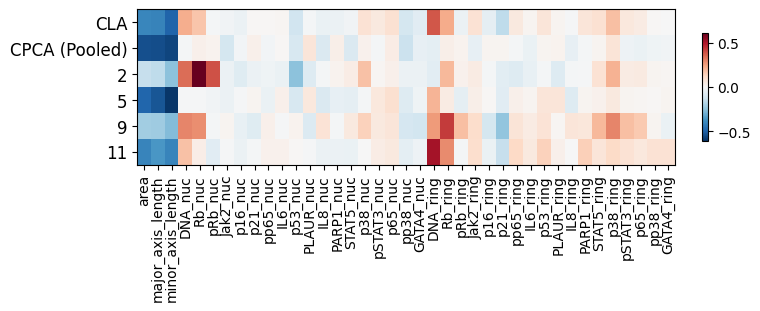

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def cov_mle(A):
    """(A - mean)^T (A - mean) / n  (p x p), symmetric."""
    A = np.asarray(A)
    A_c = A - A.mean(axis=0, keepdims=True)
    n = A.shape[0]
    return (A_c.T @ A_c) / n

def first_cpca_vector(X_fg, X_bg):
    """Return first eigenvector of cov(X_fg) - cov(X_bg)."""
    Sigma_fg = cov_mle(X_fg)
    Sigma_bg = cov_mle(X_bg)
    T = Sigma_fg - Sigma_bg
    evals, evecs = np.linalg.eigh(T)         
    order = np.argsort(evals)[::-1]          
    return evecs[:, order][:, 0]                

Y_bg = X_all[Z_arr == 0]

cols = []
labels = []

# 1) v_cla
v_cla_vec = np.asarray(v_cla[0]).reshape(-1)

cols.append(v_cla_vec)
labels.append("CLA")

# 2) CPCA for combined Z!=0
X_fg_all = X_all[Z_arr != 0]
if X_fg_all.shape[0] >= 2:
    v_cpca_all = first_cpca_vector(X_fg_all, Y_bg)
    cols.append(v_cpca_all)
    labels.append("CPCA (Pooled)")

# 3) CPCA for each individual nonzero Z
unique_nonzero_z = np.unique(Z_arr[Z_arr != 0])
unique_nonzero_z = np.sort(unique_nonzero_z)

skipped = 0
for z in unique_nonzero_z:
    X_fg_z = X_all[Z_arr == z]
    if X_fg_z.shape[0] < 2:
        skipped += 1
        continue
    v_cpca_z = first_cpca_vector(X_fg_z, Y_bg)
    cols.append(v_cpca_z)
    labels.append(f"{z}")

eigmat = np.stack(cols, axis=1)
ref = eigmat[:, 0].copy() 
ref_norm = np.linalg.norm(ref) 
for j in range(eigmat.shape[1]): 
    col = eigmat[:, j] 
    if ref_norm > 0: 
        if np.dot(col, ref) < 0: eigmat[:, j] = -col 
    else: 
        idx = np.argmax(np.abs(col)) 
        if col[idx] < 0: 
            eigmat[:, j] = -col
# use absolute loadings for display (match your previous choice)
#eigmat_disp = np.abs(eigmat)

# ---- TRANSPOSE before plotting ----
eigmat_plot = eigmat.T    

# consistent color scale
vabs = eigmat_plot.max()
vmin = eigmat_plot.min()
vmin, vmax = vmin, vabs

# Wider x-axis, shorter y-axis
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3), constrained_layout=True)
from matplotlib import colors


norm = colors.TwoSlopeNorm(
    vmin=-np.max(np.abs(eigmat_plot)),
    vcenter=0.0,
    vmax= np.max(np.abs(eigmat_plot))
)

img = ax.imshow(
    eigmat_plot,
    aspect='auto',
    cmap='RdBu_r',
    norm=norm
)
# -------------------- X-axis = FEATURES --------------------
keep_whole = {"major_axis_length", "minor_axis_length"}

simplified_features = []
for f in filtered_features:

    if f.endswith("_mean"):
        f = f[:-5]  


    if f in keep_whole:
        simplified_features.append(f)
        continue

    if "_" in f:
        simplified_features.append(f.split("_", 1)[1])
    else:
        simplified_features.append(f)

ax.set_xticks(np.arange(len(simplified_features)))
ax.set_xticklabels(simplified_features, fontsize=10, rotation=90)

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=12)

cbar = fig.colorbar(img, ax=ax, shrink=0.7)

out_path = "/Users/ericzhang/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/dissertation work/project 3 - contrastive la/senescent_heatmap_1_T.png"
#fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# -------------------------------------------------
# 1. Mask where eig1 dominates eig2
# -------------------------------------------------
abs1 = abs(v_cla_vec)
abs2 = abs(v_cpca_all)
diff = abs1-abs2
mask = abs1 > abs2
simplified_features = np.array(simplified_features)
# -------------------------------------------------
# 2. Apply mask
# -------------------------------------------------
df_filtered = pd.DataFrame({
    "feature": simplified_features[mask],
    "eig1_abs": abs1[mask],
    "eig2_abs": abs2[mask],
    "diff": diff[mask]
})

# -------------------------------------------------
# 3. Sort by difference
# -------------------------------------------------
df_filtered_sorted = df_filtered.sort_values(by="diff", ascending=False)

# -------------------------------------------------
# 4. Top features
# -------------------------------------------------
top_k = 10
top_features = df_filtered_sorted.head(top_k)

print(top_features)

       feature  eig1_abs  eig2_abs      diff
9     DNA_ring  0.380658  0.060239  0.320420
0      DNA_nuc  0.224070  0.009790  0.214280
10     Rb_ring  0.226259  0.038048  0.188212
1       Rb_nuc  0.170874  0.029274  0.141600
14    p21_ring  0.156983  0.017621  0.139362
19    p38_ring  0.184725  0.081323  0.103402
18  STAT5_ring  0.094949  0.017775  0.077175
17  PARP1_ring  0.075016  0.010985  0.064031
5      p38_nuc  0.086747  0.024304  0.062443
16    p53_ring  0.073469  0.016358  0.057111
